# Tidal phase test of `IMRPhenomXAS_NRTidalv3`

In [23]:
# Skip the complex to real warnings and the LAL warnings
import warnings
warnings.catch_warnings()
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import lal
from lal import MSUN_SI, MTSUN_SI, PC_SI
import lalsimulation as lalsim
from lalsimulation import IMRPhenomXAS_NRTidalv3, SimNRTunedTidesFDTidalPhaseFrequencySeries
MPC_SI = PC_SI * 1e6
print(lalsim.__version__)

6.2.0


In [24]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
from jax.scipy.integrate import trapezoid
import numpy as np
import matplotlib.pyplot as plt

from ripplegw import ms_to_Mc_eta, lambdas_to_lambda_tildes
from ripplegw.waveforms.IMRPhenomXAS_NRTidalv3 import gen_IMRPhenomXAS_NRTidalv3_hphc

In [25]:
# Choose the ET PSD just to have the wide frequency range
psd_freqs, *psd_arrs = np.loadtxt("psds/ET-D-psd.txt", unpack=True)
psd_arr = psd_arrs[0]

In [26]:
def get_freq_array(sampling_freqs, duration):
    # Build the frequency grid
    delta_t = 1 / sampling_freqs
    tlen = int(round(duration * sampling_freqs))
    freqs = jnp.fft.rfftfreq(tlen, delta_t)
    return freqs


def noise_weighted_inner_product(h1, h2, psd, frequencies):
    integrand = jnp.conj(h1) * h2 / psd
    return 4 * trapezoid(integrand, x=frequencies, axis=-1).real


def compute_match(h1, h2, psd, frequencies):
    h1_sq = noise_weighted_inner_product(h1, h1, psd, frequencies)
    h2_sq = noise_weighted_inner_product(h2, h2, psd, frequencies)
    h1_h2 = noise_weighted_inner_product(h1, h2, psd, frequencies)
    match = h1_h2 / jnp.sqrt(h1_sq * h2_sq)
    return match.real
    

In [27]:
from ripplegw.constants import MTSUN, PI


fs = 4096

def lal_NRTidalv3_waveform(mass_1, mass_2, a_1, a_2, inclination, phase, Lambda_1, Lambda_2,
                           duration, f_min, f_max, reference_frequency):

    laldict = lal.CreateDict()
    lalsim.SimInspiralWaveformParamsInsertTidalLambda1(laldict, Lambda_1)
    lalsim.SimInspiralWaveformParamsInsertTidalLambda2(laldict, Lambda_2)
    quad1 = lalsim.SimUniversalRelationQuadMonVSlambda2Tidal(Lambda_1)
    quad2 = lalsim.SimUniversalRelationQuadMonVSlambda2Tidal(Lambda_2)
    # Note that these are dquadmon, not quadmon, hence have to subtract 1 since that is added again later
    lalsim.SimInspiralWaveformParamsInsertdQuadMon1(laldict, quad1 - 1)
    lalsim.SimInspiralWaveformParamsInsertdQuadMon2(laldict, quad2 - 1)

    lal_hpc = lalsim.SimInspiralChooseFDWaveform(
        mass_1 * MSUN_SI,
        mass_2 * MSUN_SI,
        0, 0, a_1, 
        0, 0, a_2, 
        1,  # m
        inclination, phase,
        0., 0., 0.,
        1.0 / duration,
        f_min, f_max, 
        reference_frequency, 
        laldict,
        IMRPhenomXAS_NRTidalv3
    )
    hpc_len = len(lal_hpc[0].data.data)

    frequencies = get_freq_array(sampling_freqs=fs, duration=duration)
    zeros = jnp.zeros_like(frequencies, dtype=jnp.complex128)
    hp = zeros.at[:hpc_len].set(lal_hpc[0].data.data)
    hc = zeros.at[:hpc_len].set(lal_hpc[1].data.data)

    return frequencies, hp, hc


def ripple_NRTidalv3_waveform(mass_1, mass_2, a_1, a_2, inclination, phase, Lambda_1, Lambda_2,
                             duration, f_min, f_max, reference_frequency):

    frequencies = get_freq_array(sampling_freqs=fs, duration=duration)
    frequency_mask = (frequencies >= f_min) & (frequencies <= f_max)

    ones = jnp.ones_like(mass_1)
    chirp_mass, symmetric_mass_ratio = ms_to_Mc_eta(jnp.array([mass_1, mass_2]))
    lambda_p, lambda_m = lambdas_to_lambda_tildes(jnp.array([Lambda_1, Lambda_2, mass_1, mass_2]))

    thetas = jnp.array([
        chirp_mass, symmetric_mass_ratio, a_1, a_2, lambda_p, lambda_m, 
        ones/MPC_SI, ones*0., phase, inclination
    ])

    zeros = jnp.zeros_like(frequencies, dtype=jnp.complex128)

    @jax.jit
    def waveform(theta):
        hpc_psi_T = gen_IMRPhenomXAS_NRTidalv3_hphc(
            frequencies[frequency_mask],
            theta, reference_frequency
        )
        hp = zeros.at[frequency_mask].set(hpc_psi_T[0])
        hc = zeros.at[frequency_mask].set(hpc_psi_T[1])
        psi_T = zeros.at[frequency_mask].set(hpc_psi_T[2])
        return hp, hc, psi_T

    if thetas[0].size > 1:
        ripple_hpc = jax.vmap(waveform)(thetas.T)
    else:
        ripple_hpc = waveform(thetas)

    return frequencies, *ripple_hpc


def lal_NRTidalv3_tidal_phase_correction(mass_1, mass_2, a_1, a_2, Lambda_1, Lambda_2,
                                            duration):

    frequencies = get_freq_array(sampling_freqs=fs, duration=duration)
    phi_tidal = np.zeros_like(frequencies)
    amp_tidal = np.zeros_like(frequencies)
    planck_taper = np.zeros_like(frequencies)

    NRTidal_version = lalsim.NRTidalv3_V 
    _ = SimNRTunedTidesFDTidalPhaseFrequencySeries(
            phi_tidal,
            amp_tidal,
            planck_taper,
            frequencies,
            mass_1 * MSUN_SI,
            mass_2 * MSUN_SI,
            Lambda_1,
            Lambda_2,
            a_1,
            a_2,
            NRTidal_version
    )

    return jnp.array(phi_tidal)

## Compare `LALSimulation` and `Ripple` waveforms

In [29]:
seed = 10
Nsamples = 500
duration = 16.0
f_min = 5.0
f_max = fs / 2

rand_arr = jax.random.uniform(jax.random.PRNGKey(seed), 
                              (8, Nsamples), dtype=jnp.float64)
total_mass = rand_arr[0] * 5.5 + 0.5
mass_ratio = rand_arr[1] * 0.95 + 0.05
mass_1 = total_mass / (1 + mass_ratio)
mass_2 = total_mass - mass_1
spin_1z, spin_2z = jnp.zeros((2, Nsamples)) #rand_arr[2:4] * 2 - 1
inclination = rand_arr[4] * jnp.pi
phase = rand_arr[5] * 2 * jnp.pi
Lambda_1, Lambda_2 = rand_arr[6:] * 10000

thetas = jnp.vstack([
    mass_1, mass_2, spin_1z, spin_2z, inclination, phase, Lambda_1, Lambda_2
])
thetas_intrinsic = jnp.vstack([
    mass_1, mass_2, spin_1z, spin_2z, Lambda_1, Lambda_2
])

lal_Tidalv3_wfms = []
lal_Tidalv3_phases = []
for theta in thetas.T:
    theta = np.array(theta)
    _, *lal_hpc = lal_NRTidalv3_waveform(
        *theta, duration=duration,
        f_min=f_min, f_max=f_max,
        reference_frequency=f_min
    )
    lal_Tidalv3_wfms.append(lal_hpc)
    
    lal_phase_corr = lal_NRTidalv3_tidal_phase_correction(
        theta[0], theta[1], theta[2], theta[3], theta[6], theta[7],
        duration
    )
    lal_Tidalv3_phases.append(lal_phase_corr)

_, *ripple_Tidalv3_hpc_psi_T = ripple_NRTidalv3_waveform(
    *thetas, duration=duration,
    f_min=f_min, f_max=f_max,
    reference_frequency=f_min
)

lal_Tidalv3_hpc = jnp.array(lal_Tidalv3_wfms).transpose(1,0,2)
lal_Tidalv3_phases = jnp.array(lal_Tidalv3_phases)
ripple_Tidalv3_hpc = jnp.array(ripple_Tidalv3_hpc_psi_T[:2])
ripple_Tidalv3_phases = jnp.array(ripple_Tidalv3_hpc_psi_T[2])

In [30]:
frequencies = get_freq_array(sampling_freqs=fs, duration=duration)
interp_psd = jnp.interp(frequencies, psd_freqs, psd_arr)
Tidalv3_match_hp = compute_match(lal_Tidalv3_hpc[0], ripple_Tidalv3_hpc[0], interp_psd, frequencies)
Tidalv3_match_hc = compute_match(lal_Tidalv3_hpc[1], ripple_Tidalv3_hpc[1], interp_psd, frequencies)

In [31]:
lal_Tidalv3_phases_zerod = np.array(lal_Tidalv3_phases)
lal_Tidalv3_phases_zerod[:,0] = 0.0 # filter out nans at f=0
dphase_Tidalv3 = np.abs(lal_Tidalv3_phases_zerod - ripple_Tidalv3_phases)

max_dphases = np.max(dphase_Tidalv3, axis=1)

In [32]:
log_mismatches = np.log10(1 - Tidalv3_match_hp)
# log_mismatches = np.where(np.isfinite(log_mismatches), log_mismatches, -20)

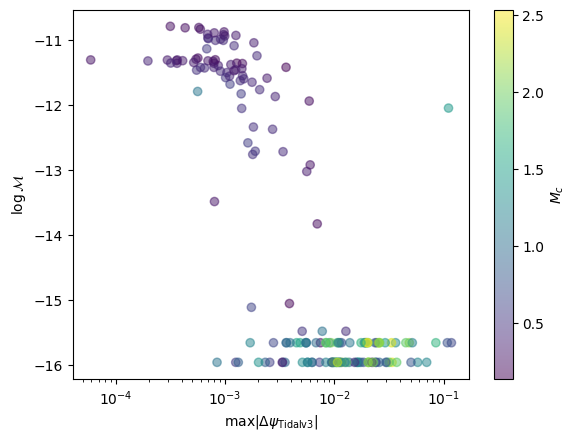

In [33]:
chirp_mass, eta = ms_to_Mc_eta(thetas_intrinsic[:2])

plt.scatter(np.max(dphase_Tidalv3, axis=1), log_mismatches, alpha=0.5, c=chirp_mass, cmap='viridis')
plt.xscale('log')
plt.xlabel(r"$\max|\Delta \psi_{\mathrm{Tidalv3}}|$")
plt.ylabel(r"$\log{\mathcal{M}}$")
plt.colorbar(label=r'$M_c$')
plt.show()

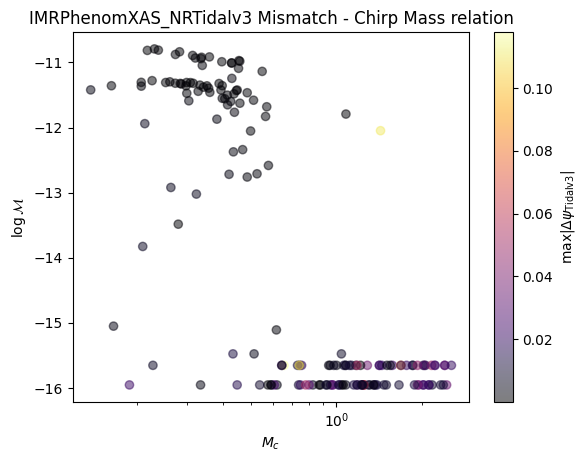

In [34]:
plt.scatter(chirp_mass, np.log10(1 - Tidalv3_match_hp), alpha=0.5, c=np.max(dphase_Tidalv3, axis=1), cmap='inferno')
plt.title("IMRPhenomXAS_NRTidalv3 Mismatch - Chirp Mass relation")
plt.xscale('log')
plt.xlabel(r'$M_c$')
plt.ylabel(r"$\log{\mathcal{M}}$")
plt.colorbar(label=r"$\max|\Delta \psi_{\mathrm{Tidalv3}}|$")
plt.show()

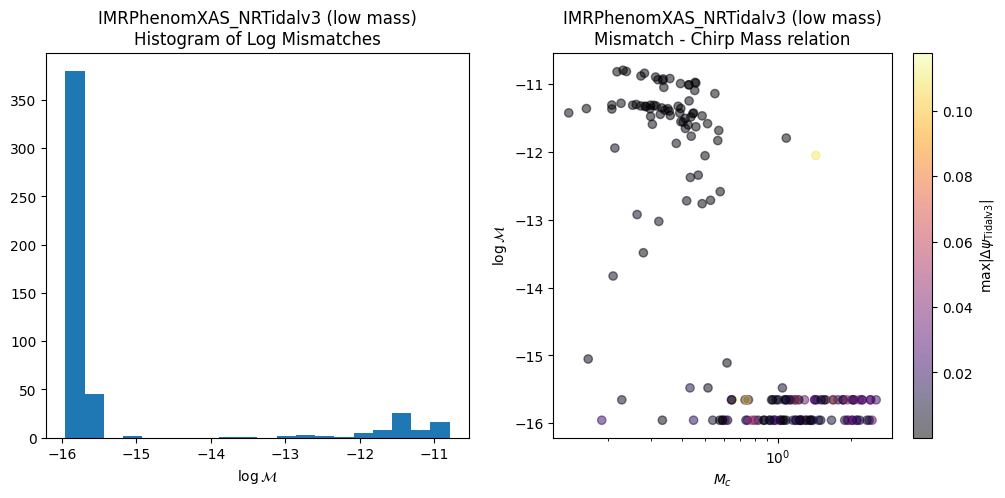

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

hist_data = np.where(np.isfinite(log_mismatches), log_mismatches, min(np.where(np.isfinite(log_mismatches), log_mismatches, 100)))
axs[0].hist(hist_data, bins=20)
axs[0].set_title("IMRPhenomXAS_NRTidalv3 (low mass)\nHistogram of Log Mismatches")
axs[0].set_xlabel(r"$\log{\mathcal{M}}$")

sc = axs[1].scatter(chirp_mass, np.log10(1 - Tidalv3_match_hp), alpha=0.5, c=np.max(dphase_Tidalv3, axis=1), cmap='inferno')
axs[1].set_title("IMRPhenomXAS_NRTidalv3 (low mass)\nMismatch - Chirp Mass relation")
axs[1].set_xscale('log')
axs[1].set_xlabel(r'$M_c$')
axs[1].set_ylabel(r"$\log{\mathcal{M}}$")
fig.colorbar(sc, ax=axs[1], label=r"$\max|\Delta \psi_{\mathrm{Tidalv3}}|$")

# fig.savefig("/home/robinc/jax_gw/ripple/test/nrtidalv3_figures/ZeroSpin_mismatches.png")
plt.show()

In [ ]:
mismatch_mask = np.log10(1 - Tidalv3_match_hp) > -14

for Mtot, dphase, mismatch in zip(total_mass[mismatch_mask], dphase_Tidalv3[mismatch_mask], np.log10(1 - Tidalv3_match_hp)[mismatch_mask]):
    plt.plot(Mtot * MTSUN * frequencies, dphase, alpha=0.3)

plt.title(r"IMRPhenomXAS_NRTidalv3 Phase Error ($\log{\mathcal{M}} > 10^{-14}$)")
plt.xlabel(r'$Mf$')
plt.ylabel(r'$|\Delta \psi_{\mathrm{Tidalv3}}|$')
plt.xscale('log')
plt.yscale('log')
plt.show()

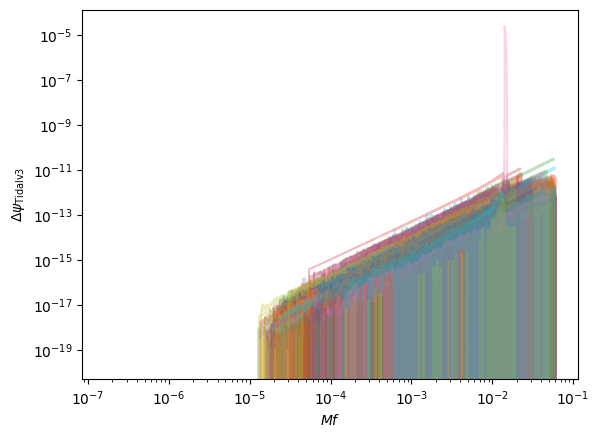

In [37]:
dphase_pure = lal_Tidalv3_phases - ripple_Tidalv3_phases

for Mtot, dphase in zip(total_mass, dphase_pure):
    plt.plot(Mtot * MTSUN * frequencies, dphase, alpha=0.3)

plt.xlabel(r'$Mf$')
plt.ylabel(r'$\Delta \psi_{\mathrm{Tidalv3}}$')
plt.xscale('log')
plt.yscale('log')
plt.show()

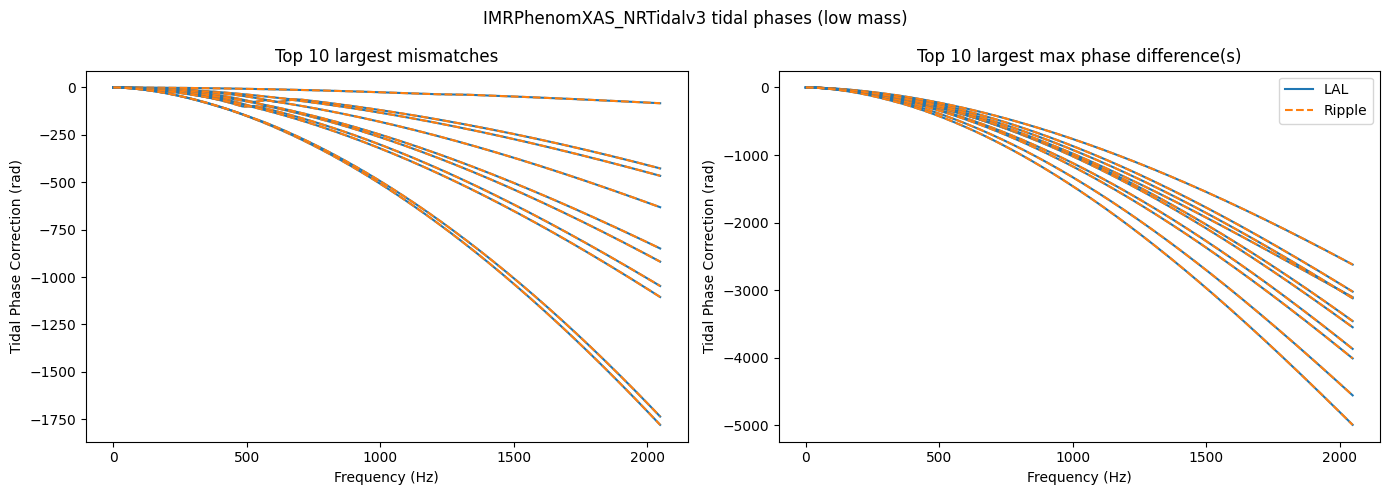

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("IMRPhenomXAS_NRTidalv3 tidal phases (low mass)")

# Left: Top mismatches
mismatch_values = np.log10(1 - Tidalv3_match_hp)
top_idx = 10
top_indices_mismatch = np.argsort(mismatch_values)[-top_idx:]
mismatch_mask_VERYhigh = np.zeros(len(mismatch_values), dtype=bool)
mismatch_mask_VERYhigh[top_indices_mismatch] = True

top_lal_mismatch = lal_Tidalv3_phases[mismatch_mask_VERYhigh]
top_ripple_mismatch = ripple_Tidalv3_phases[mismatch_mask_VERYhigh]

for i in range(top_idx):
    lal_label = 'LAL' if i == 0 else None
    ripple_label = 'Ripple' if i == 0 else None
    axs[0].plot(frequencies, top_lal_mismatch[i], label=lal_label, color='C0')
    axs[0].plot(frequencies, top_ripple_mismatch[i], label=ripple_label, color='C1', ls='--')

axs[0].set_title(f'Top {top_idx} largest mismatches')
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Tidal Phase Correction (rad)')
# axs[0].legend()

# Right: Top phase differences
max_phase_diff = np.max(dphase_Tidalv3, axis=1)
top_indices_phase = np.argsort(max_phase_diff)[-top_idx:]
phase_mask_VERYhigh = np.zeros(len(max_phase_diff), dtype=bool)
phase_mask_VERYhigh[top_indices_phase] = True

top_lal_phase = lal_Tidalv3_phases[phase_mask_VERYhigh]
top_ripple_phase = ripple_Tidalv3_phases[phase_mask_VERYhigh]

for i in range(top_idx):
    lal_label = 'LAL' if i == 0 else None
    ripple_label = 'Ripple' if i == 0 else None
    axs[1].plot(frequencies, top_lal_phase[i], label=lal_label, color='C0')
    axs[1].plot(frequencies, top_ripple_phase[i], label=ripple_label, ls='--', color='C1')

axs[1].set_title(f'Top {top_idx} largest max phase difference(s)')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Tidal Phase Correction (rad)')
axs[1].legend()

fig.tight_layout()
# fig.savefig("/home/robinc/jax_gw/ripple/test/nrtidalv3_figures/LowMass_tidal_phase_corr.png")
plt.show()

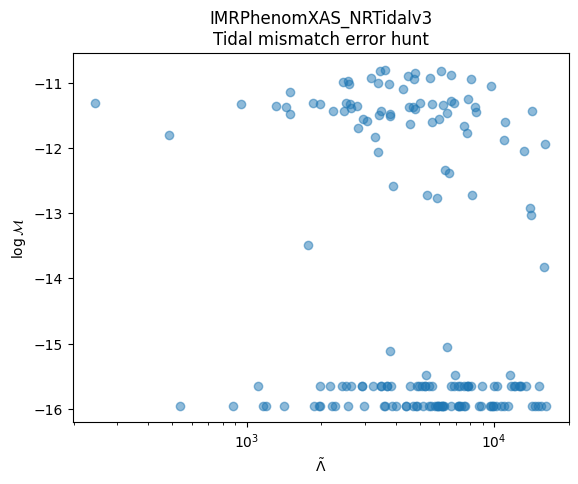

In [39]:
lambda_p, lambda_m = lambdas_to_lambda_tildes(jnp.array([Lambda_1, Lambda_2, mass_1, mass_2]))

plt.scatter(lambda_p, log_mismatches, alpha=0.5)
plt.title("IMRPhenomXAS_NRTidalv3\nTidal mismatch error hunt")
plt.xlabel(r"$\tilde{\Lambda}$")
plt.ylabel(r"$\log{\mathcal{M}}$")
plt.xscale('log')
plt.show()